In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df=pd.read_excel("Telco_customer_churn.xlsx")

In [99]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [100]:
df.shape

(7043, 33)

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [102]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


no value in churn reason is missing sice only those who left the company will give the reasons

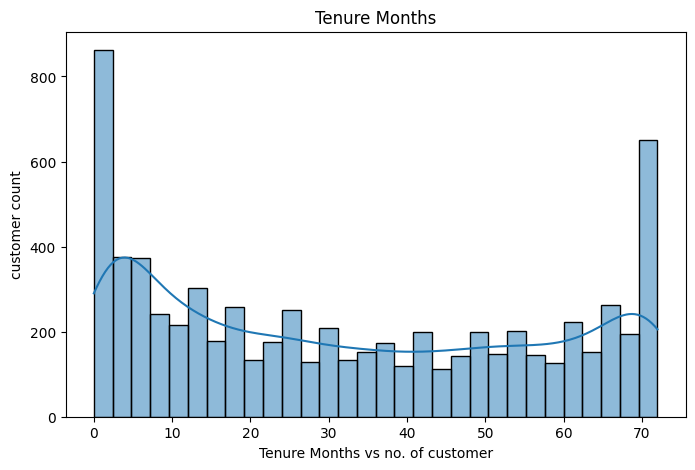

In [103]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'] , bins=30 , kde=True)
plt.title('Tenure Months')
plt.xlabel('Tenure Months vs no. of customer')
plt.ylabel('customer count')
plt.show()

In [104]:
df['Tenure Months'].max()

72

In [105]:
df['Tenure Months'].min()

0

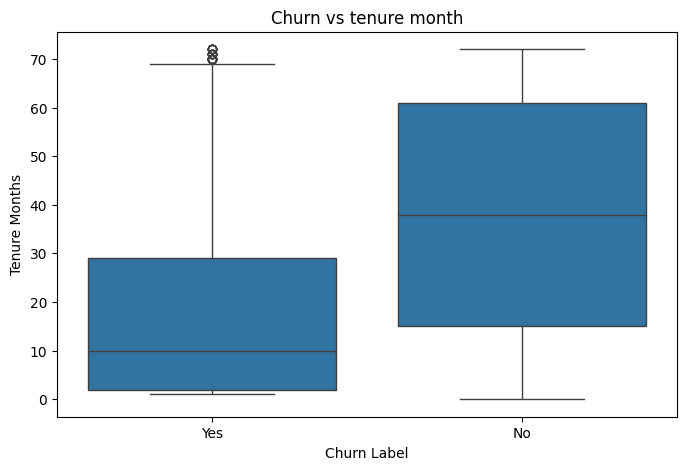

In [106]:
plt.figure(figsize=(8,5))
sns.boxplot(y='Tenure Months' , x= 'Churn Label' , data=df)
plt.title('Churn vs tenure month')
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.show()

In [107]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [108]:
df['Churn Label']=='Yes'

,Churn Label
0,True
1,True
2,True
3,True
4,True
...,...
7038,False
7039,False
7040,False
7041,False


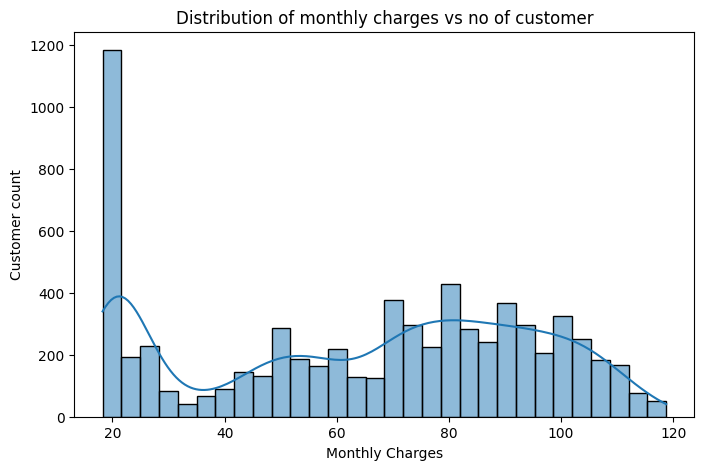

In [109]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.title('Distribution of monthly charges vs no of customer')
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.show()

In [110]:
df['Monthly Charges'].min()

18.25

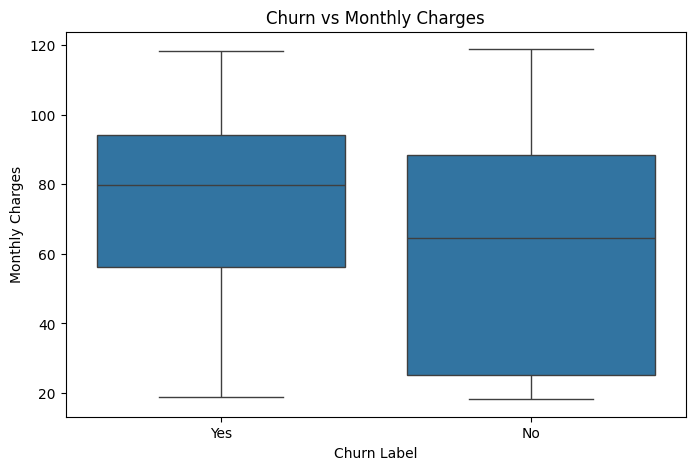

In [111]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label',y='Monthly Charges',data=df)
plt.title('Churn vs Monthly Charges')
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.show()

In [112]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [113]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [114]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [115]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [116]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [117]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


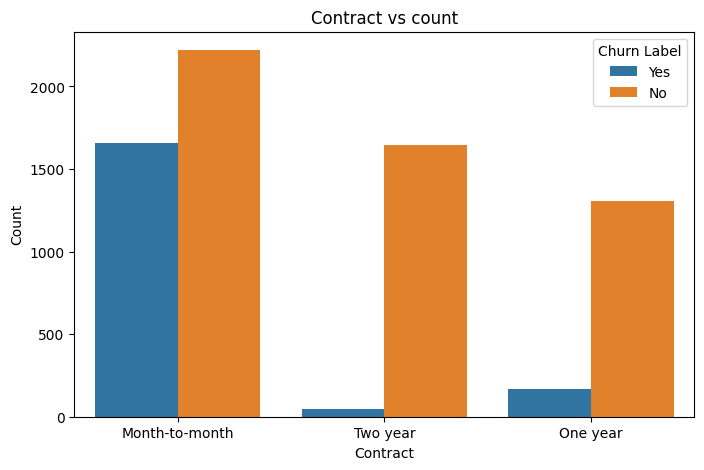

In [118]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract',hue='Churn Label',data=df)
plt.title('Contract vs count')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.show()

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [120]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

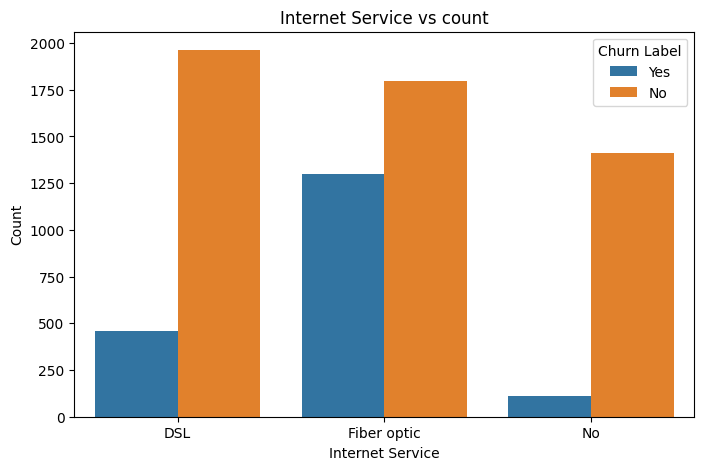

In [121]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service',hue='Churn Label',data=df)
plt.title('Internet Service vs count')
plt.xlabel('Internet Service')
plt.ylabel('Count')
plt.show()

In [122]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

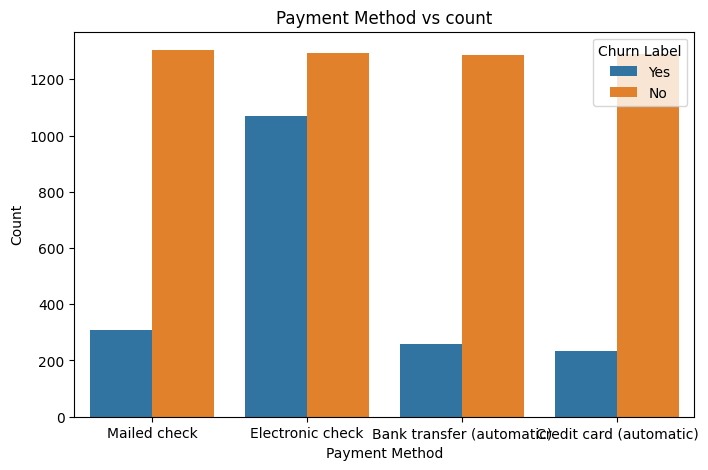

In [123]:
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method',hue='Churn Label',data=df)
plt.title('Payment Method vs count')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.show()

In [124]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

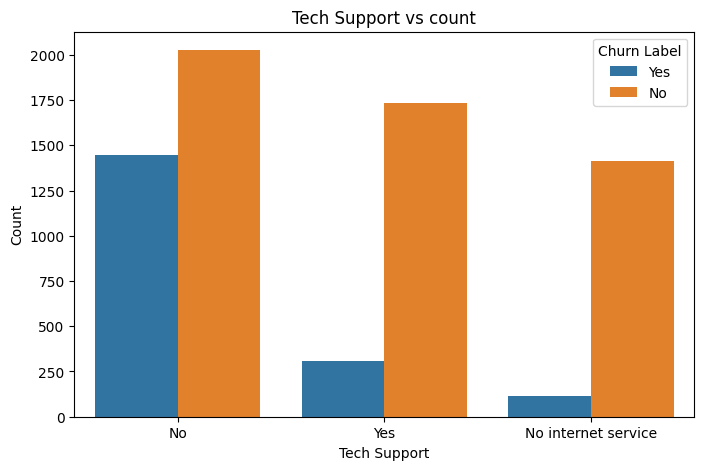

In [125]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support',hue='Churn Label',data=df)
plt.title('Tech Support vs count')
plt.xlabel('Tech Support')
plt.ylabel('Count')
plt.show()

In [126]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [127]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','CLTV']
correlation_matrix=df[numerical_cols].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,CLTV
Tenure Months,1.000000,0.247900,-0.352229,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.098693
Churn Value,-0.352229,0.193356,1.000000,-0.127463
CLTV,0.396406,0.098693,-0.127463,1.000000


In [128]:
import pandas as pd
contract_churn= pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


DATA CLEANING

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [130]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [131]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [132]:
drop_columns=['CustomerID','Count','Country','State','City','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']
df=df.drop(columns=drop_columns)

In [133]:
df_encoded=pd.get_dummies(df,drop_first=True)
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [134]:
df_encoded.shape

(7043, 31)

In [135]:
X=df_encoded.drop('Churn Value',axis=1)
Y=df_encoded['Churn Value']
X.shape
Y.shape

(7043,)

In [136]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [137]:
print(Y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


Machine Learning implementation

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.33, random_state=42)

In [140]:
X_train.shape

(4718, 30)

In [141]:
Y_train.shape

(4718,)

In [142]:
from sklearn.ensemble import RandomForestClassifier

In [143]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [144]:
rf_model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [145]:
y_pred=rf_model.predict(X_test)

In [146]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [147]:
from sklearn.metrics import accuracy_score

In [148]:
accuracy=accuracy_score(Y_test,y_pred)
print(accuracy)

0.7944086021505377


In [149]:
from sklearn.metrics import confusion_matrix

In [150]:
cm=confusion_matrix(Y_test,y_pred)

In [151]:
cm

array([[1507,  177],
       [ 301,  340]])

In [152]:
from sklearn.metrics import classification_report

In [153]:
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1684
           1       0.66      0.53      0.59       641

    accuracy                           0.79      2325
   macro avg       0.75      0.71      0.73      2325
weighted avg       0.79      0.79      0.79      2325



**Approach 1- Handle class imbalance**

In [154]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(X_train,Y_train)
y_pred_balanced=rf_balanced.predict(X_test)
accuracy_balanced=accuracy_score(Y_test,y_pred_balanced)
cm_balanced=confusion_matrix(Y_test,y_pred_balanced)
print(accuracy_balanced,cm_balanced)
print(classification_report(Y_test,y_pred_balanced))

0.792258064516129 [[1517  167]
 [ 316  325]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1684
           1       0.66      0.51      0.57       641

    accuracy                           0.79      2325
   macro avg       0.74      0.70      0.72      2325
weighted avg       0.78      0.79      0.78      2325



**Approach-2 Hyperparameter Tuning**

In [155]:
rf_tuned=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_tuned.fit(X_train,Y_train)
y_pred_tuned=rf_tuned.predict(X_test)

**Approach 3**

In [156]:
import pandas as pd
feature_importance=pd.DataFrame({'Features':X.columns,'Importance':rf_tuned.feature_importances_})
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

                                  Features  Importance
2                            Total Charges    0.174936
0                            Tenure Months    0.168788
1                          Monthly Charges    0.149540
25                       Contract_Two year    0.055201
6                           Dependents_Yes    0.046163
10            Internet Service_Fiber optic    0.041164
28         Payment Method_Electronic check    0.036818
24                       Contract_One year    0.027382
26                   Paperless Billing_Yes    0.025108
3                              Gender_Male    0.024296
13                     Online Security_Yes    0.023933
5                              Partner_Yes    0.023662
19                        Tech Support_Yes    0.020599
15                       Online Backup_Yes    0.019154
9                       Multiple Lines_Yes    0.017321
4                       Senior Citizen_Yes    0.017187
23                    Streaming Movies_Yes    0.016765
17        

In [157]:
print(feature_importance.tail(15))

                                  Features  Importance
4                       Senior Citizen_Yes    0.017187
23                    Streaming Movies_Yes    0.016765
17                   Device Protection_Yes    0.016257
21                        Streaming TV_Yes    0.016124
27  Payment Method_Credit card (automatic)    0.013924
29             Payment Method_Mailed check    0.011918
12     Online Security_No internet service    0.010496
16   Device Protection_No internet service    0.008300
11                     Internet Service_No    0.006247
18        Tech Support_No internet service    0.006218
20        Streaming TV_No internet service    0.005555
22    Streaming Movies_No internet service    0.004837
7                        Phone Service_Yes    0.004519
14       Online Backup_No internet service    0.003810
8          Multiple Lines_No phone service    0.003782


In [158]:
X_selected=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [159]:
X_train_sel, X_test_sel, Y_train_sel, Y_test_sel = train_test_split(
    X_selected, Y, test_size=0.2, random_state=42)

In [160]:
rf_selected=RandomForestClassifier(n_estimators=300,random_state=42,max_depth=10,class_weight='balanced')
rf_selected.fit(X_train_sel,Y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)
print(classification_report(Y_test_sel,y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.78      0.79      1409



**Approach- Combination of Trees and Depth**

In [161]:

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]

# Re-split X and Y to ensure X_train and Y_train have consistent sample sizes
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=42)

for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,random_state=42,max_depth=depth,class_weight='balanced')
    rf.fit(X_train,Y_train)
    y_pred=rf.predict(X_test)
    accuracy=accuracy_score(Y_test,y_pred)
    recall=recall_score(Y_test,y_pred)
    precision=precision_score(Y_test,y_pred)
    f1=f1_score(Y_test,y_pred)
    results.append({'Trees':n_trees,'Depth':depth,'Accuracy':accuracy,'Recall':recall,'Precision':precision,'F1':f1})

result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy    Recall  Precision        F1
8     300      5  0.752258  0.822153   0.532861  0.646626
16    500      5  0.751398  0.820593   0.531850  0.645399
12    400      5  0.750968  0.820593   0.531313  0.645003
4     200      5  0.753118  0.815913   0.534219  0.645679
0     100      5  0.750968  0.808112   0.531828  0.641486
17    500     10  0.781935  0.751950   0.580723  0.655337
13    400     10  0.783226  0.750390   0.583030  0.656207
9     300     10  0.781935  0.748830   0.581114  0.654397
1     100     10  0.781505  0.748830   0.580411  0.653951
5     200     10  0.783226  0.745710   0.583639  0.654795
14    400     15  0.798710  0.619345   0.639291  0.629160
18    500     15  0.796989  0.617785   0.635634  0.626582
10    300     15  0.795699  0.613105   0.633871  0.623315
2     100     15  0.793548  0.603744   0.631321  0.617225
6     200     15  0.796559  0.602184   0.639073  0.620080
19    500     20  0.796989  0.535101   0.663443  0.592401
15    400     

In [162]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')

In [163]:
cv_accuracy=cross_val_score(final_rf,X,Y,cv=5,scoring='accuracy')
print(cv_accuracy)

[0.78637331 0.8012775  0.77430802 0.79474432 0.80042614]


In [164]:
cv_accuracy.mean()

np.float64(0.7914258581198788)

In [165]:
cv_recall=cross_val_score(final_rf,X,Y,cv=5,scoring='recall')
print(cv_recall)

[0.44117647 0.5        0.47058824 0.48395722 0.52010724]


In [166]:
cv_recall.mean()

np.float64(0.4831658327479175)

**Optional**

In [167]:
from sklearn.metrics import roc_auc_score,roc_curve

In [168]:
import matplotlib.pyplot as plt

In [169]:
y_prob=rf_tuned.predict_proba(X)

In [170]:
y_prob1=rf_tuned.predict_proba(X_test)

In [171]:
churn_prob=y_prob[:,1]

In [172]:
churn_prob=y_prob1[:,1]

In [173]:
fpr,tpr,threshold=roc_curve(Y_test,churn_prob)
auc_score=roc_auc_score(Y_test,churn_prob)
print(auc_score)

0.8368238648785857


**Customer Segmentation**

In [174]:
segmentation_data=pd.DataFrame({
    'Tenure Months':X_test['Tenure Months'],
    'Monthly Charges':X_test['Monthly Charges'],
    'Total Charges':X_test['Total Charges'],
    'Churn  Probability':churn_prob
})

In [175]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
185,15,85.9,1269.55,0.34
2715,18,56.8,1074.65,0.11
3825,2,20.0,40.90,0.05
1807,6,84.2,519.15,0.65
132,40,104.8,4131.95,0.35
...,...,...,...,...
4147,46,81.0,3846.35,0.01
3542,40,20.6,827.30,0.00
3759,2,19.2,37.20,0.43
1114,13,75.3,989.45,0.42


**Implementation**

In [176]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [177]:
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-0.70457096  0.67853888 -0.45229585  0.24893968]
 [-0.58174825 -0.29542436 -0.53802995 -0.60208553]
 [-1.23680273 -1.52710296 -0.9927638  -0.8240921 ]
 [-1.07303911  0.62164068 -0.78238753  1.39597364]
 [ 0.31895166  1.31111294  0.80683853  0.28594077]]


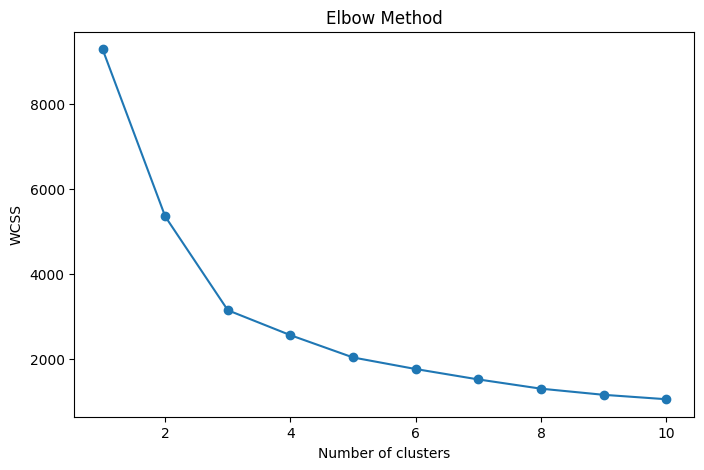

In [178]:
from sklearn.cluster import KMeans
import numpy as np

wcss=[]

# Impute NaN values in scaled_data before using it for KMeans
# This ensures KMeans receives data without missing values.
# Check if scaled_data is already a NumPy array before iterating through columns
if isinstance(scaled_data, np.ndarray):
    for i in range(scaled_data.shape[1]):
        if np.isnan(scaled_data[:, i]).any():
            median_val = np.nanmedian(scaled_data[:, i])
            scaled_data[:, i] = np.nan_to_num(scaled_data[:, i], nan=median_val)
else:
    # Handle case where scaled_data might not be a numpy array, e.g., if it's a pandas DataFrame.
    # For this specific context, it's expected to be a numpy array.
    print("Warning: scaled_data is not a numpy array. NaN imputation skipped.")

for k in range(1,11): # Looping from 1 to 10 clusters for Elbow Method
  kmeans=KMeans(n_clusters=k,random_state=42, n_init=10) # Added n_init to suppress future warning
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

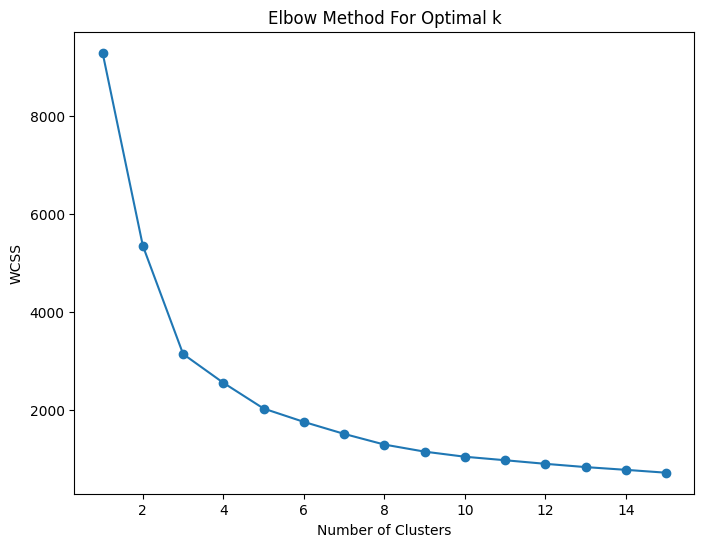

In [179]:
from sklearn.cluster import KMeans
import numpy as np # Ensure numpy is imported for nanmedian and nan_to_num

wcss=[]

# Impute NaN values in scaled_data before using it for KMeans
# This ensures KMeans receives data without missing values.
for i in range(scaled_data.shape[1]):
    if np.isnan(scaled_data[:, i]).any():
        median_val = np.nanmedian(scaled_data[:, i])
        scaled_data[:, i] = np.nan_to_num(scaled_data[:, i], nan=median_val)

for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42, n_init=10) # Added n_init to suppress future warning
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)

# Plotting the Elbow Method results after the loop
plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal k') # Added title for clarity
plt.show()

In [180]:
 kmeans=KMeans(n_clusters=k,random_state=42)

In [181]:
clusters=kmeans.fit_predict(scaled_data)

In [182]:
segmentation_data['Cluster']=clusters

In [183]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
185,15,85.9,1269.55,0.34,5
2715,18,56.8,1074.65,0.11,11
3825,2,20.0,40.90,0.05,3
1807,6,84.2,519.15,0.65,7
132,40,104.8,4131.95,0.35,10
...,...,...,...,...,...
4147,46,81.0,3846.35,0.01,10
3542,40,20.6,827.30,0.00,9
3759,2,19.2,37.20,0.43,14
1114,13,75.3,989.45,0.42,6


In [184]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [185]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,38.368421,96.537500,3708.894079,0.622500
1,60.993590,23.091346,1402.883013,0.013846
2,68.348101,106.789873,7316.837658,0.071392
3,8.802139,21.996791,200.193243,0.089636
4,2.375000,39.188068,101.648864,0.690948
5,22.925926,89.444753,2032.691049,0.413642
6,6.732143,77.404464,519.857738,0.472624
7,5.665138,84.797477,499.552064,0.811226
8,52.331081,57.218581,2977.635811,0.103784


In [186]:
cluster_names={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'Loyal Premium Customers'
}

In [187]:
segmentation_data['Cluster segment']=segmentation_data['Cluster'].map(cluster_names)

In [188]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster segment
185,15,85.9,1269.55,0.34,5,NaN
2715,18,56.8,1074.65,0.11,11,NaN
3825,2,20.0,40.90,0.05,3,NaN
1807,6,84.2,519.15,0.65,7,NaN
132,40,104.8,4131.95,0.35,10,NaN
...,...,...,...,...,...,...
4147,46,81.0,3846.35,0.01,10,NaN
3542,40,20.6,827.30,0.00,9,NaN
3759,2,19.2,37.20,0.43,14,NaN
1114,13,75.3,989.45,0.42,6,NaN


In [189]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Monthly Charges', ylabel='Churn  Probability'>

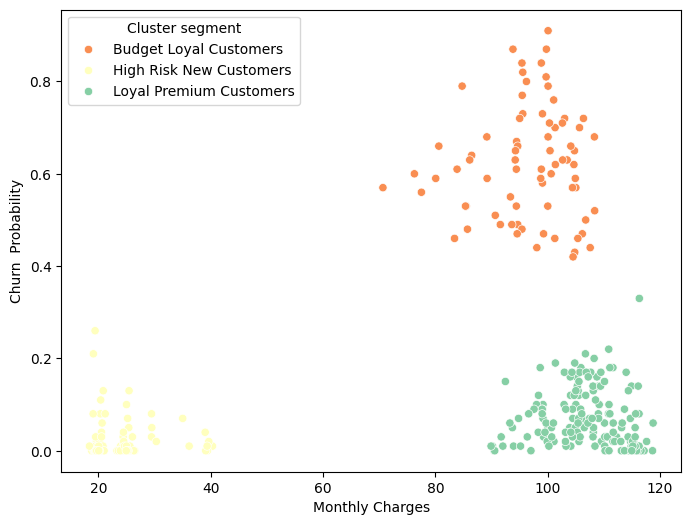

In [190]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn  Probability',hue='Cluster segment',data=segmentation_data,palette='Spectral')

<Axes: xlabel='Tenure Months', ylabel='Churn  Probability'>

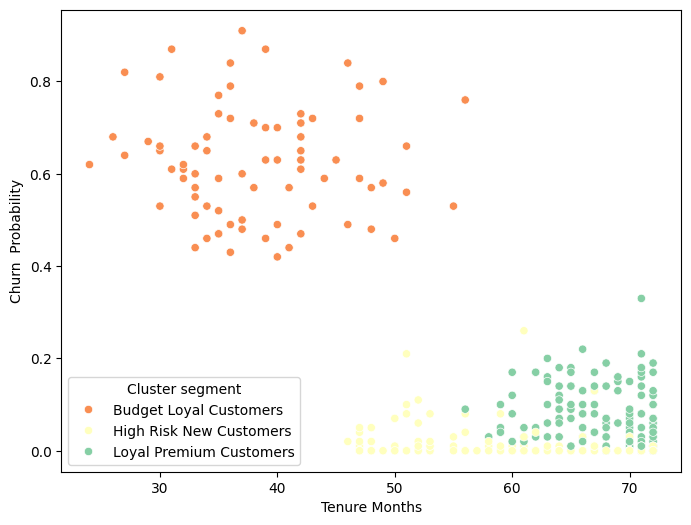

In [191]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Churn  Probability',hue='Cluster segment',data=segmentation_data,palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='Churn  Probability'>

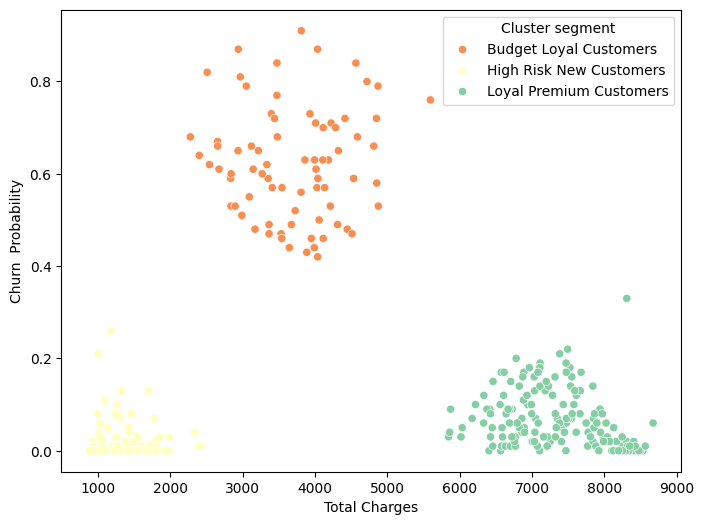

In [192]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges',y='Churn  Probability',hue='Cluster segment',data=segmentation_data,palette='Spectral')